In [134]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import OpenAI
from typing import TypedDict
from dotenv import load_dotenv
import json

In [135]:
load_dotenv()
class BlgState(TypedDict):
    scale:int
    rate:int
    topic:str
    outline:str
    refined_content:str    

In [136]:
llm = OpenAI(
    model="gpt-4o-mini"
)

In [155]:
def generate_outline(state:BlgState)->BlgState:
    topic = state["topic"]
    query = f'Generate outline for requested blog topic:{topic}'
    llm_response =llm.invoke(
        query
    )
    state["outline"] =  llm_response   
    return state

In [154]:
def generate_final_content(state: BlgState) -> BlgState:
    query = f"Generate content for the requested outline in 1000 characters only strictly: {state['outline']}"
    llm_response = llm.invoke(query)
    state["refined_content"] = llm_response
    return state

In [158]:
def rate_and_scale_Content(state: BlgState) -> BlgState:
    query = f"""
Based on the outline below:
{state['outline']}

Generate integer rating and scale for the refined blog content below.
Return only valid JSON with keys "rating" and "scale".

{state['refined_content']}
"""
    response = llm.invoke(query)
    text = getattr(response, "content", None) or response
    json_response = json.loads(text)
    state["rate"] = json_response.get("rating", 0)
    state["scale"] = json_response.get("scale", 0)
    return state

In [160]:

graph = StateGraph(BlgState)
graph.add_node("generate_outline",generate_outline)
graph.add_node("generate_final_content",generate_final_content)
graph.add_node("rate_and_scale_Content",rate_and_scale_Content)
graph.add_edge(START,"generate_outline")
graph.add_edge("generate_outline","generate_final_content")
graph.add_edge("generate_final_content","rate_and_scale_Content")
graph.add_edge("rate_and_scale_Content",END)

workflow = graph.compile()

stateInput = {'topic':'Create blog content for the AI in India'}
result = workflow.invoke(stateInput)
print(f'Refined contents are {result["refined_content"]}\n Rate is: {result["rate"]} and scale is {result["scale"]}')




Refined contents are     B. Call to action for stakeholders to invest in AI development
    C. Vision for an AI-driven future in India

India is set to become a global AI powerhouse, with its burgeoning market driven by diverse industries like healthcare, finance, retail, and agriculture embracing AI technologies. The government's National AI Strategy and initiatives foster innovation through public-private partnerships and funding. Key players include established tech giants and innovative startups, while research institutions and international collaborations further enrich the ecosystem. Challenges such as a lack of skilled talent, infrastructure gaps, and ethical concerns must be addressed. As AI trends evolve, opportunities abound in automation, data analytics, and smart solutions. Stakeholders must invest in AI development to harness its potential, paving the way for an AI-driven future that will significantly enhance India's economic growth and societal progress. Together, we can

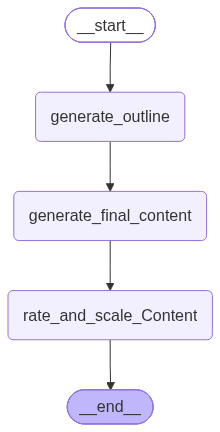

In [161]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())